# Movement Island Study: Descriptive Statistics and Correlations

**Study:** Psychological Factors Influencing Behavioral Intention to Recommend the Movement Island for Older Adults

**Author:** Aurel Berger

**Date:** February 2026

---

## Overview

This notebook replicates the descriptive statistics and correlation analyses reported in the paper:

- **Table 1:** Sample Demographics (N=16)
- **Table 2:** Descriptive Statistics for TAM Constructs
- **Figure 1:** Pearson Correlations Among TAM Constructs

All analyses use the cleaned data from N=16 participants who completed the survey after interacting with the Movement Island prototype.

## 1. Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 2. Load Data

In [2]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_data_full.csv')

print(f"✓ Data loaded: N = {len(df)}")
print(f"✓ Variables: {df.shape[1]} columns")
print(f"\nFirst few columns: {list(df.columns[:10])}")

✓ Data loaded: N = 16
✓ Variables: 42 columns

First few columns: ['Respondent ID', 'Collector ID', 'Start Date', 'End Date', 'IP Address', 'Email Address', 'First Name', 'Last Name', 'Custom Data 1', 'PU1']


## 3. Calculate Composite Scores

TAM constructs are measured with 3 items each (7-point Likert scale).
Composite scores are calculated as the mean of the three items.

In [3]:
# Define item groups for each construct
constructs = {
    'PU': ['PU1', 'PU2', 'PU3'],
    'PEOU': ['PEOU1', 'PEOU2', 'PEOU3'],
    'PE': ['PE1', 'PE2', 'PE3'],
    'PS': ['PS1', 'PS2', 'PS3'],
    'BI': ['BI1', 'BI2', 'BI3']
}

# Calculate composite scores
for construct, items in constructs.items():
    df[f'{construct}_composite'] = df[items].mean(axis=1)

print("✓ Composite scores calculated")
print(f"\nComposite variables created:")
for construct in constructs.keys():
    print(f"  - {construct}_composite")

✓ Composite scores calculated

Composite variables created:
  - PU_composite
  - PEOU_composite
  - PE_composite
  - PS_composite
  - BI_composite


## 4. Table 1: Sample Demographics

In [10]:
# Define demographic variables
age_col = 'Age group'
comfort_col = 'How comfortable are you with everyday digital technologies (e.g., smartphones, computers, apps)?'
care_col = 'Do you currently or have you ever had a close relative or friend living in a care home?'
healthcare_col = 'Do you currently work in a healthcare or care profession?'

print("="*70)
print("TABLE 1: SAMPLE DEMOGRAPHICS (N=16)")
print("="*70)

# Age group
print("\nAge Group:")
age_freq = df[age_col].value_counts().sort_index()
for category, count in age_freq.items():
    pct = (count / len(df)) * 100
    print(f"  {category:<20} n={count:2d}  ({pct:4.0f}%)")

# Digital comfort
print("\nDigital Technology Comfort:")
comfort_order = ['Moderately comfortable', 'Quite comfortable', 'Very comfortable', 'Extremely comfortable']
for category in comfort_order:
    count = (df[comfort_col] == category).sum()
    if count > 0:
        pct = (count / len(df)) * 100
        print(f"  {category:<25} n={count:2d}  ({pct:4.0f}%)")

# Care home familiarity
print("\nCare Home Familiarity:")
care_freq = df[care_col].value_counts()
for category, count in care_freq.items():
    pct = (count / len(df)) * 100
    print(f"  {category:<20} n={count:2d}  ({pct:4.0f}%)")

# Healthcare profession
print("\nHealthcare Profession:")
healthcare_freq = df[healthcare_col].value_counts()
for category, count in healthcare_freq.items():
    pct = (count / len(df)) * 100
    print(f"  {category:<20} n={count:2d}  ({pct:4.0f}%)")

print("\n" + "="*70)

# Save to CSV
demographics_summary = pd.DataFrame({
    'Variable': ['Age', 'Digital Comfort', 'Care Home', 'Healthcare'],
    'Details': [
        f"Most common: {age_freq.idxmax()}",
        f"High comfort: {((df[comfort_col].isin(['Very comfortable', 'Extremely comfortable'])).sum())} (75%)",
        f"Yes: {(df[care_col]=='Yes').sum()} (38%)",
        f"Yes: {(df[healthcare_col]=='Yes').sum()} (19%)"
    ]
})
demographics_summary.to_csv('../outputs/table1_demographics.csv', index=False)
print("\n✓ Table 1 saved to: outputs/table1_demographics.csv")

TABLE 1: SAMPLE DEMOGRAPHICS (N=16)

Age Group:
  18–24                n= 2  (  12%)
  25–34                n= 8  (  50%)
  35–44                n= 2  (  12%)
  45–54                n= 1  (   6%)
  55+                  n= 3  (  19%)

Digital Technology Comfort:
  Moderately comfortable    n= 1  (   6%)
  Quite comfortable         n= 3  (  19%)
  Very comfortable          n= 5  (  31%)
  Extremely comfortable     n= 7  (  44%)

Care Home Familiarity:
  No                   n=10  (  62%)
  Yes                  n= 6  (  38%)

Healthcare Profession:
  No                   n=11  (  69%)
  Yes                  n= 3  (  19%)


✓ Table 1 saved to: outputs/table1_demographics.csv


## 5. Table 2: Descriptive Statistics for TAM Constructs

In [11]:
# Calculate descriptive statistics
composite_cols = [f'{c}_composite' for c in constructs.keys()]
descriptives = df[composite_cols].describe().T

# Format output
descriptives_table = pd.DataFrame({
    'Construct': ['Perceived Usefulness (PU)', 'Perceived Ease of Use (PEOU)', 
                  'Perceived Enjoyment (PE)', 'Perceived Safety (PS)', 
                  'Behavioral Intention (BI)'],
    'M': descriptives['mean'].values,
    'SD': descriptives['std'].values,
    'Min': descriptives['min'].values,
    'Max': descriptives['max'].values
})

print("="*70)
print("TABLE 2: DESCRIPTIVE STATISTICS FOR TAM CONSTRUCTS (N=16)")
print("="*70)
print(f"\n{'Construct':<30} {'M':>6} {'SD':>6} {'Min':>6} {'Max':>6}")
print("-"*70)
for _, row in descriptives_table.iterrows():
    print(f"{row['Construct']:<30} {row['M']:>6.2f} {row['SD']:>6.2f} {row['Min']:>6.2f} {row['Max']:>6.2f}")
print("="*70)

# Save to CSV
descriptives_table.to_csv('../outputs/table2_descriptives.csv', index=False)
print("\n✓ Table 2 saved to: outputs/table2_descriptives.csv")

TABLE 2: DESCRIPTIVE STATISTICS FOR TAM CONSTRUCTS (N=16)

Construct                           M     SD    Min    Max
----------------------------------------------------------------------
Perceived Usefulness (PU)        6.00   0.64   4.33   7.00
Perceived Ease of Use (PEOU)     5.60   0.70   4.67   7.00
Perceived Enjoyment (PE)         5.88   0.76   4.00   7.00
Perceived Safety (PS)            5.90   0.77   4.33   7.00
Behavioral Intention (BI)        6.10   0.66   4.67   7.00

✓ Table 2 saved to: outputs/table2_descriptives.csv


## 6. Correlation Matrix (Composite Scores)

In [12]:
# Calculate Pearson correlations
corr_matrix = df[composite_cols].corr()

# Rename for clarity
corr_matrix.index = ['PU', 'PEOU', 'PE', 'PS', 'BI']
corr_matrix.columns = ['PU', 'PEOU', 'PE', 'PS', 'BI']

print("="*70)
print("PEARSON CORRELATIONS AMONG TAM CONSTRUCTS (N=16)")
print("="*70)
print("\n" + corr_matrix.round(3).to_string())
print("\n" + "="*70)

# Calculate p-values
n = len(df)
print("\nKey correlations:")
for i, construct1 in enumerate(['PU', 'PEOU', 'PE', 'PS', 'BI']):
    for j, construct2 in enumerate(['PU', 'PEOU', 'PE', 'PS', 'BI']):
        if i < j:
            r = corr_matrix.loc[construct1, construct2]
            # Calculate p-value
            t_stat = r * np.sqrt((n-2)/(1-r**2))
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            if abs(r) > 0.5:  # Only show strong correlations
                print(f"  {construct1} - {construct2}: r = {r:.3f}, p = {p_val:.3f} {sig}")

# Save correlation matrix
corr_matrix.to_csv('../outputs/correlation_matrix_constructs.csv')
print("\n✓ Correlation matrix saved to: outputs/correlation_matrix_constructs.csv")

PEARSON CORRELATIONS AMONG TAM CONSTRUCTS (N=16)

         PU   PEOU     PE     PS     BI
PU    1.000  0.393  0.834  0.600  0.745
PEOU  0.393  1.000  0.207  0.207  0.190
PE    0.834  0.207  1.000  0.638  0.793
PS    0.600  0.207  0.638  1.000  0.561
BI    0.745  0.190  0.793  0.561  1.000


Key correlations:
  PU - PE: r = 0.834, p = 0.000 ***
  PU - PS: r = 0.600, p = 0.014 *
  PU - BI: r = 0.745, p = 0.001 ***
  PE - PS: r = 0.638, p = 0.008 **
  PE - BI: r = 0.793, p = 0.000 ***
  PS - BI: r = 0.561, p = 0.024 *

✓ Correlation matrix saved to: outputs/correlation_matrix_constructs.csv


## 7. Figure 1: Correlation Heatmap

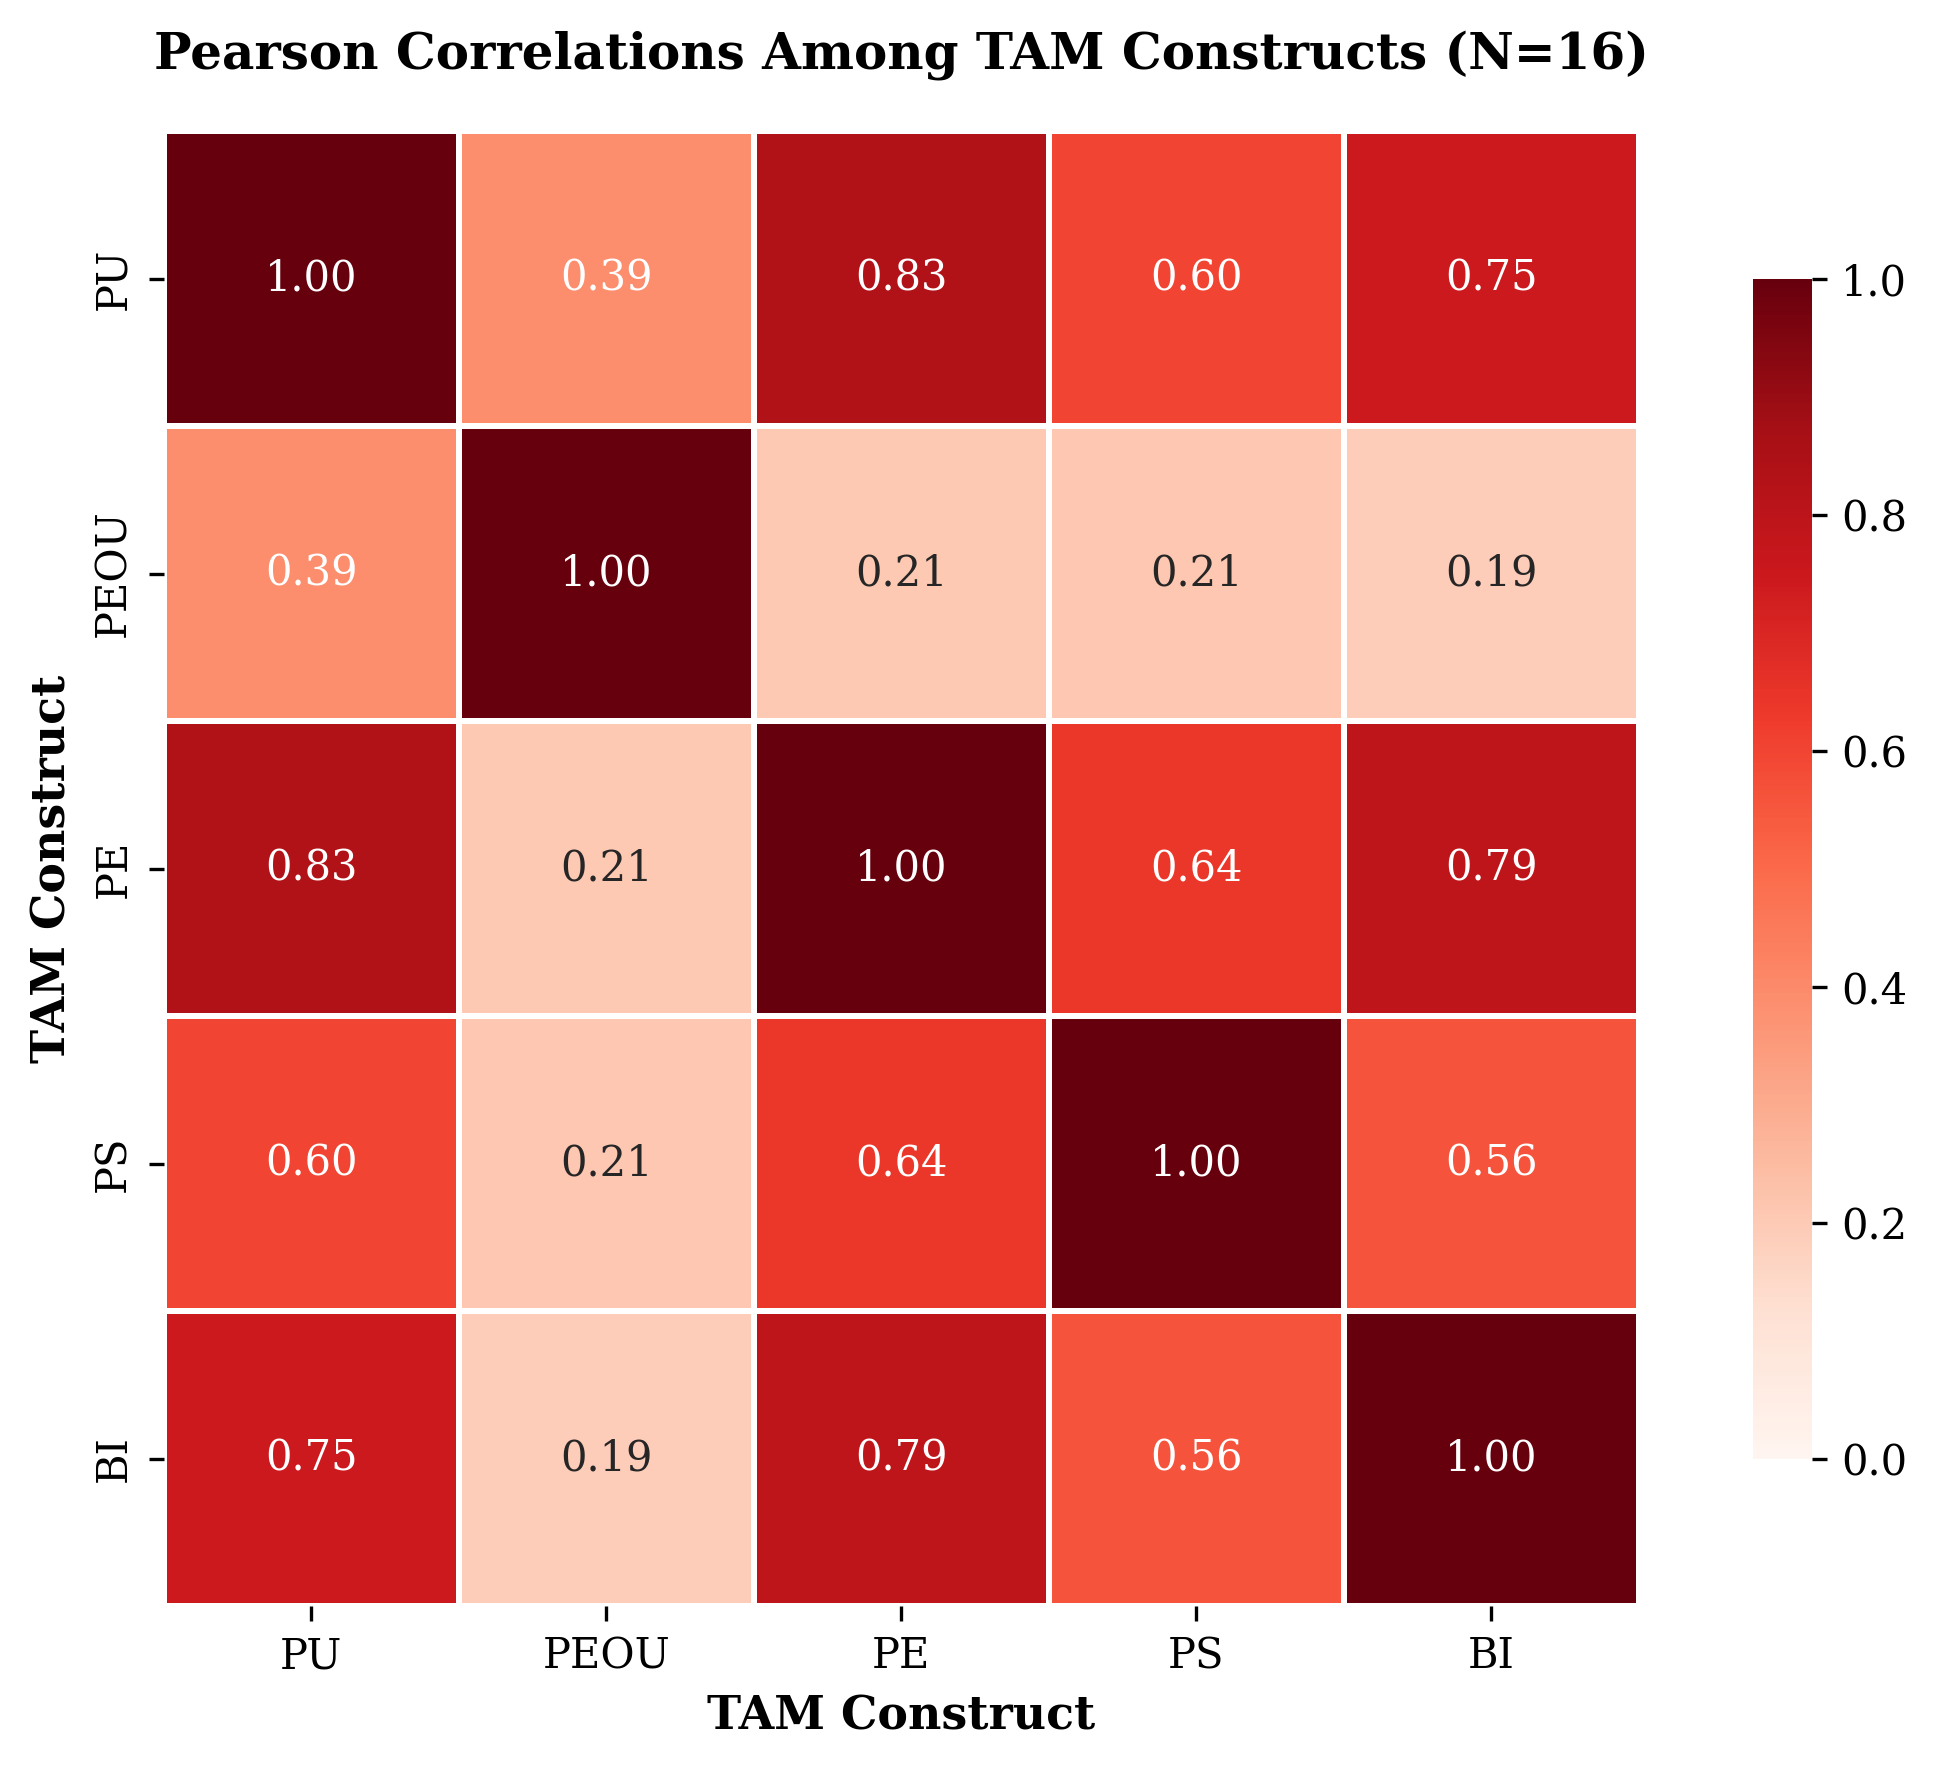

✓ Figure 1 saved to: figures/figure1_correlation_heatmap.png


In [13]:
# Create correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Reds', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1, ax=ax)

# Labels
ax.set_xlabel('TAM Construct', fontweight='bold', fontsize=11)
ax.set_ylabel('TAM Construct', fontweight='bold', fontsize=11)
ax.set_title('Pearson Correlations Among TAM Constructs (N=16)', 
             fontweight='bold', pad=15, fontsize=12)

plt.tight_layout()
plt.savefig('../figures/figure1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved to: figures/figure1_correlation_heatmap.png")

## 8. Summary Statistics

Key findings from descriptive analyses:

In [14]:
print("="*70)
print("SUMMARY OF KEY FINDINGS")
print("="*70)

print("\n1. Sample Characteristics:")
print(f"   - Total participants: N = {len(df)}")
print(f"   - Most common age group: {df[age_col].mode()[0]}")
print(f"   - High digital comfort: {(df[comfort_col].isin(['Very comfortable', 'Extremely comfortable'])).sum()} participants (75%)")

print("\n2. TAM Construct Means (1-7 scale):")
for construct in ['PU', 'PEOU', 'PE', 'PS', 'BI']:
    col = f'{construct}_composite'
    print(f"   - {construct}: M = {df[col].mean():.2f}, SD = {df[col].std():.2f}")

print("\n3. Strongest Correlations:")
# Flatten correlation matrix and sort
corr_pairs = []
for i, construct1 in enumerate(['PU', 'PEOU', 'PE', 'PS', 'BI']):
    for j, construct2 in enumerate(['PU', 'PEOU', 'PE', 'PS', 'BI']):
        if i < j:
            corr_pairs.append((construct1, construct2, corr_matrix.loc[construct1, construct2]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, r in corr_pairs[:3]:
    print(f"   - {c1} - {c2}: r = {r:.3f}")

print("\n" + "="*70)
print("✓ All descriptive analyses completed successfully!")
print("="*70)

SUMMARY OF KEY FINDINGS

1. Sample Characteristics:
   - Total participants: N = 16
   - Most common age group: 25–34
   - High digital comfort: 12 participants (75%)

2. TAM Construct Means (1-7 scale):
   - PU: M = 6.00, SD = 0.64
   - PEOU: M = 5.60, SD = 0.70
   - PE: M = 5.88, SD = 0.76
   - PS: M = 5.90, SD = 0.77
   - BI: M = 6.10, SD = 0.66

3. Strongest Correlations:
   - PU - PE: r = 0.834
   - PE - BI: r = 0.793
   - PU - BI: r = 0.745

✓ All descriptive analyses completed successfully!
